In [13]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import shap

import xgboost as xgb

In [ ]:
def evaluate_model(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print("WYNIKI MODELU")
    print(f"R^2 Score: {r2:.4f}")
    print(f"MAE:        ${mae:,.2f}")
    print(f"RMSE:       ${rmse:,.2f}")
    print(f"std:        ${np.std(y_test):,.2f}")

    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, y_pred, alpha=0.4)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())


    return mae, rmse, r2

In [6]:
data = pd.read_csv('../data/merged/data_model.csv')
data

,runtime,year,budget_adjusted,revenue_adjusted,quarter,director_movie_count,writer_movie_count,actors_avg_movie_count,writer_avg_revenue,writer_max_revenue,...,kw_romantic_comedy,kw_new_york_city,kw_serial_killer,kw_revenge,kw_musical,kw_small_town,kw_superhero,kw_alien,kw_biography,kw_fantasy_world
0,98,1995,8.449948e+06,8.993604e+06,4,15,13,8.2,2.384469e+08,5.964630e+08,...,0,0,0,0,0,0,0,0,0,0
1,109,1993,4.678756e+07,2.704085e+07,4,9,9,3.6,7.272651e+07,1.714053e+08,...,0,0,0,0,0,0,0,0,0,0
2,100,2003,1.644709e+08,1.645296e+09,2,9,7,12.4,1.081580e+09,1.645296e+09,...,0,0,0,0,0,0,0,0,0,0
3,142,1994,1.194795e+08,1.471527e+09,2,20,13,21.8,3.225962e+08,1.471527e+09,...,0,0,0,0,0,0,0,0,0,0
4,122,1999,2.898646e+07,6.885186e+08,3,9,1,9.0,6.885186e+08,6.885186e+08,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9181,137,2025,2.000000e+07,4.227859e+08,3,1,1,1.0,4.227859e+08,4.227859e+08,...,0,0,0,0,0,0,0,0,0,0
9182,224,2025,6.500000e+07,3.500000e+06,4,6,1,2.6,3.500000e+06,3.500000e+06,...,0,0,0,1,0,0,0,0,0,0
9183,88,2023,1.056583e+04,5.599891e+04,2,1,1,1.0,5.599891e+04,5.599891e+04,...,0,0,0,1,0,0,0,0,0,0
9184,127,2025,1.600000e+06,1.472934e+06,4,3,1,1.2,1.472934e+06,1.472934e+06,...,0,0,0,0,0,0,0,0,0,0


In [7]:
print(data.shape)
q_low = data['revenue_adjusted'].quantile(0.01)
q_high = data['revenue_adjusted'].quantile(0.99)
data_filtered = data[(data['revenue_adjusted'] >= q_low) & (data['revenue_adjusted'] <= q_high)].copy()
data_filtered.shape

(9186, 87)


(9002, 87)

In [8]:
X = data_filtered.drop(columns=['revenue_adjusted'])
y = data_filtered['revenue_adjusted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_features = X.columns.tolist()

# RF

## Pełny model

WYNIKI MODELU
R^2 Score: 0.8823
MAE:        $28,086,754.26
RMSE:       $63,409,921.56
std:        $184,818,060.44


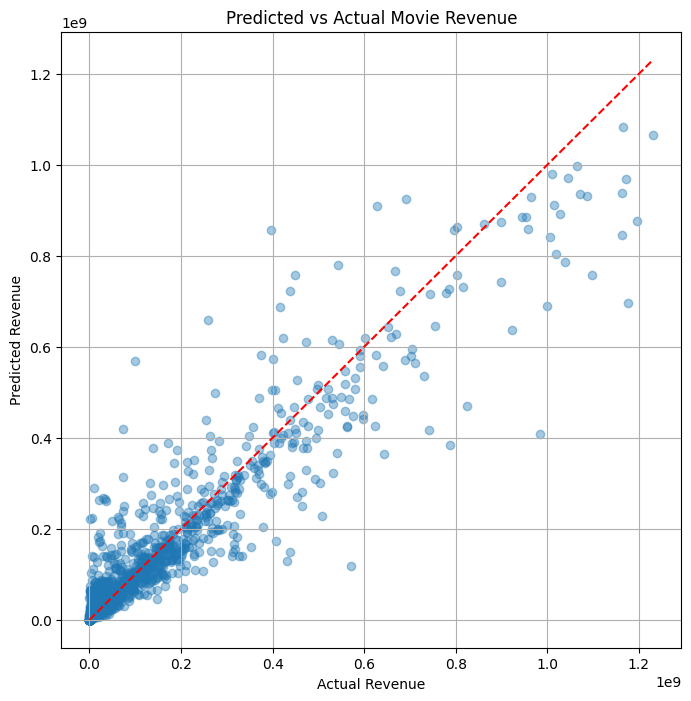

(28086754.259275895, 63409921.56393132, 0.882286678194294)

In [11]:
rf = RandomForestRegressor(n_estimators=600, max_depth=13, min_samples_split=2, min_samples_leaf=3, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
evaluate_model(y_test, y_pred)

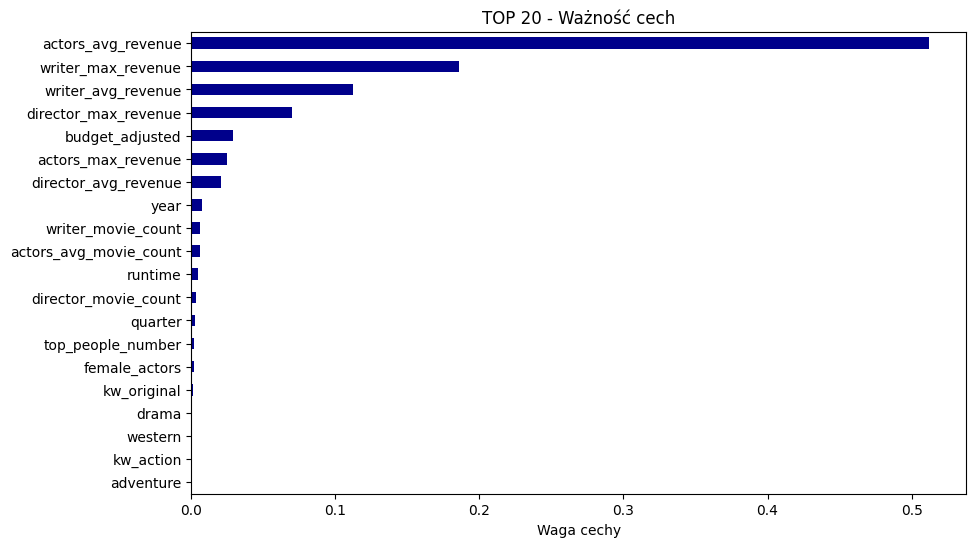

In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(10,6))
importances.plot(kind='barh', color='darkblue').invert_yaxis()
plt.title("TOP 20 - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()

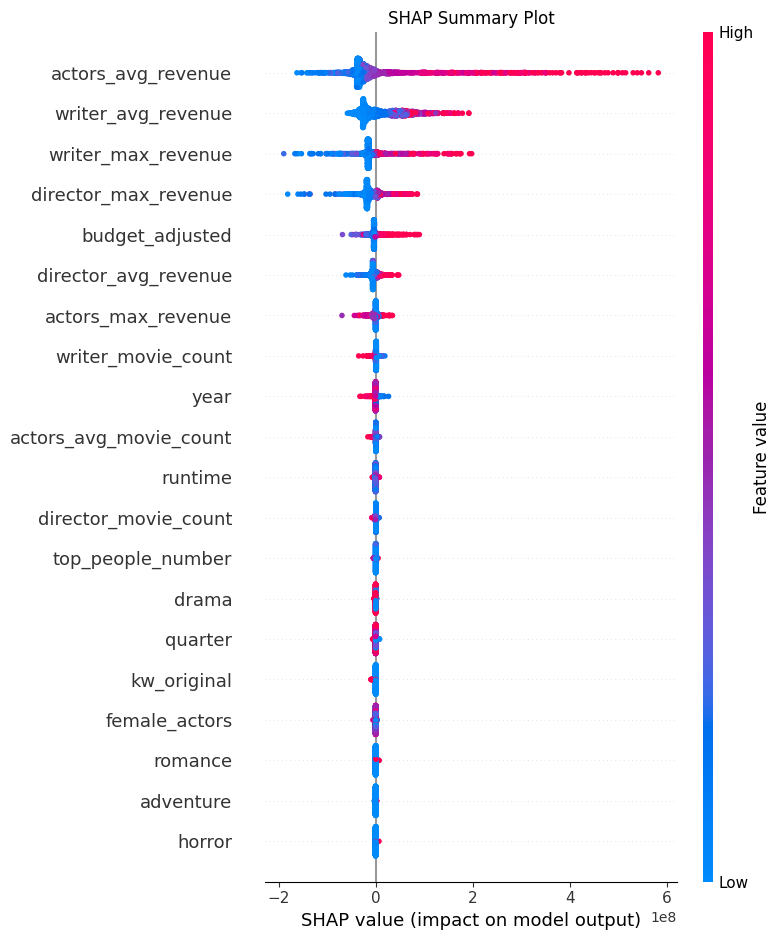

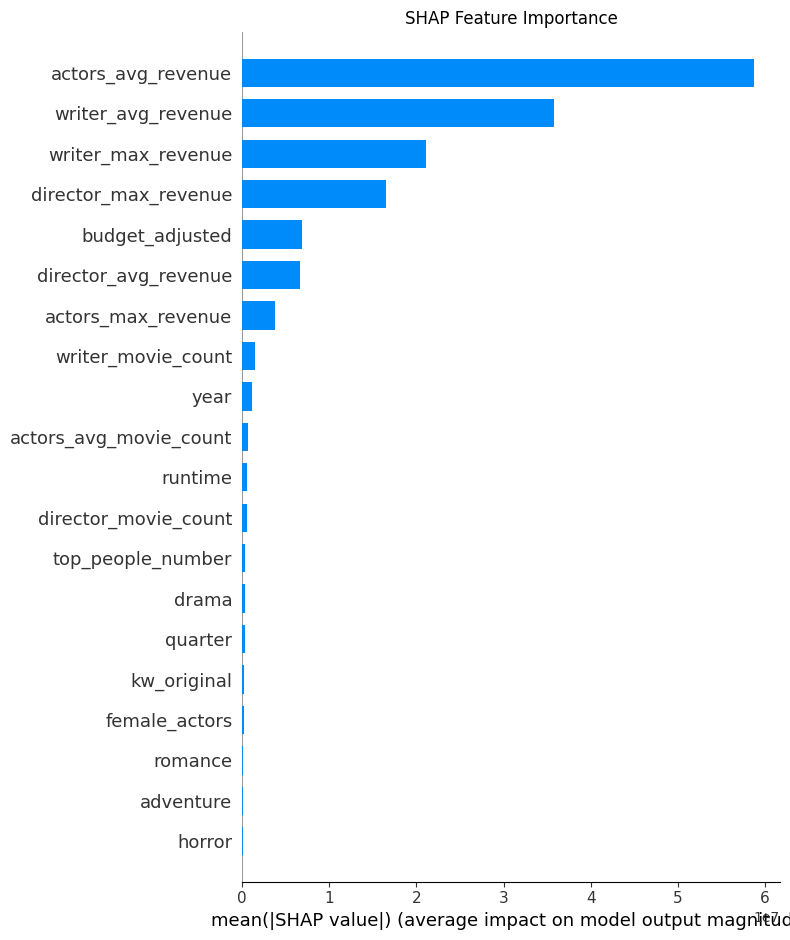

In [18]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test) 


plt.figure(figsize=(10, 6))

shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

## Zmniejszone modele

--- WYBRANO 8 NAJWAŻNIEJSZYCH CECH ---
1. actors_avg_revenue
2. writer_max_revenue
3. writer_avg_revenue
4. director_max_revenue
5. budget_adjusted
6. actors_max_revenue
7. director_avg_revenue
8. year

Najlepsze parametry po CV:
{'n_estimators': 600, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 13}

EWALUACJA ZREDUKOWANEGO MODELU
WYNIKI MODELU
R^2 Score: 0.8826
MAE:        $28,089,309.10
RMSE:       $63,336,555.65
std:        $184,818,060.44


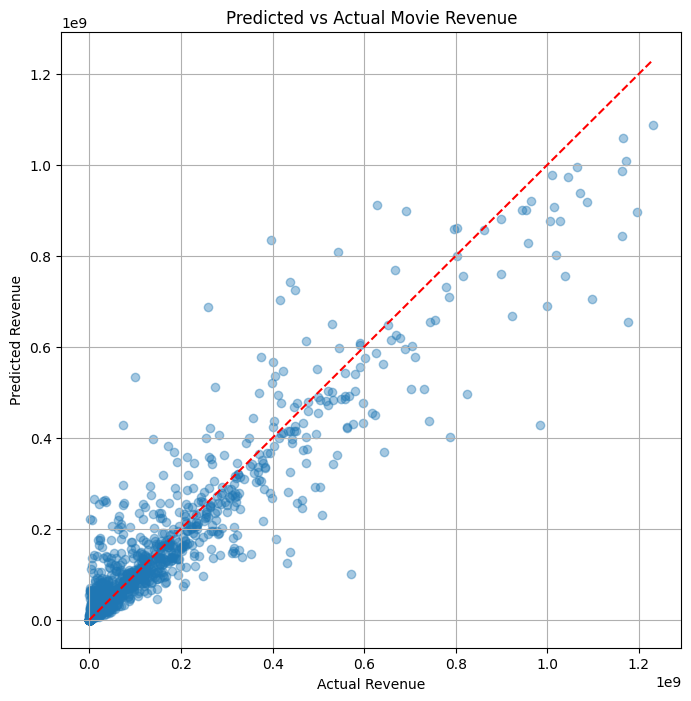

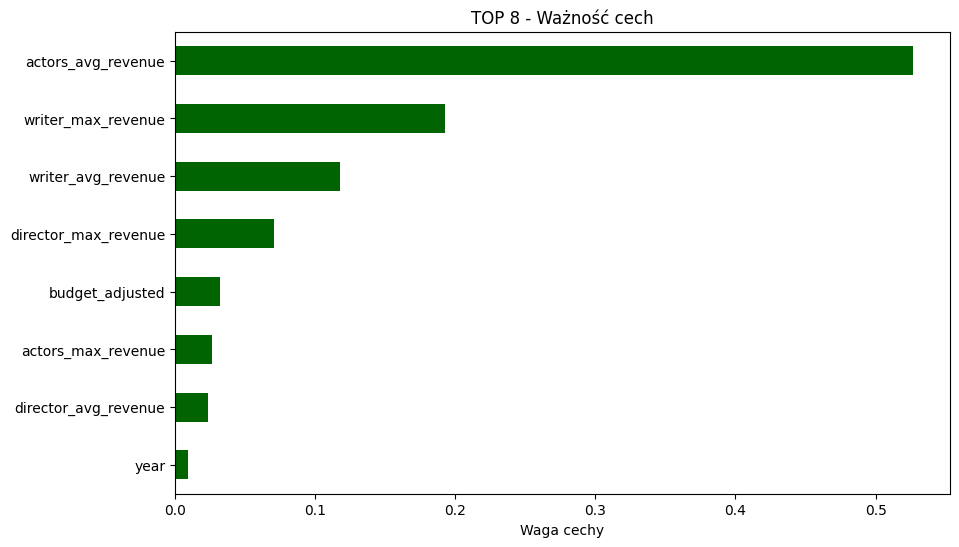

Obliczam SHAP dla nowego modelu...


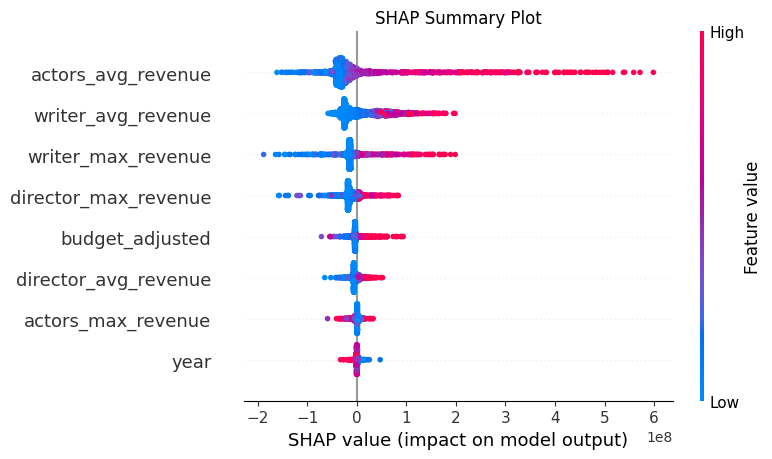

In [ ]:
# MODEL NAJWAŻNIEJSZE CECHY (DLA IMPORTANCE I SHAP SĄ ONE IDENTYCZNE)

TOP_N = 8  

top_features = importances.head(TOP_N).index.tolist()

print(f"--- WYBRANO {TOP_N} NAJWAŻNIEJSZYCH CECH ---")
for i, col in enumerate(top_features, 1):
    print(f"{i}. {col}")

X_train_sub = X_train[top_features]
X_test_sub = X_test[top_features]


param_grid = {
    'n_estimators': [100, 300, 500, 600],
    'max_depth': [5, 10, 13, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4]
}

rf_cv = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_cv.fit(X_train_sub, y_train)
best_rf = rf_cv.best_estimator_

print("\nNajlepsze parametry po CV:")
print(rf_cv.best_params_)


print("\nEWALUACJA ZREDUKOWANEGO MODELU")
y_pred_sub = best_rf.predict(X_test_sub)
evaluate_model(y_test, y_pred_sub) 

#  Ważność cech dla nowego modelu
importances_sub = pd.Series(best_rf.feature_importances_, index=top_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_sub.plot(kind='barh', color='darkgreen').invert_yaxis()
plt.title(f"TOP {TOP_N} - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()

# SHAP dla nowego modelu
print("SHAP dla nowego modelu...")
explainer_sub = shap.TreeExplainer(best_rf)
shap_values_sub = explainer_sub.shap_values(X_test_sub)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_sub, X_test_sub, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()


WYBRANO 8 CECH
1. runtime
2. quarter
3. budget_adjusted
4. year
5. actors_avg_movie_count
6. director_movie_count
7. writer_max_revenue
8. writer_avg_revenue

Najlepsze parametry po Cross-Walidacji:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}
WYNIKI MODELU
R^2 Score: 0.6920
MAE:        $47,928,222.06
RMSE:       $102,571,420.18
std:        $184,818,060.44


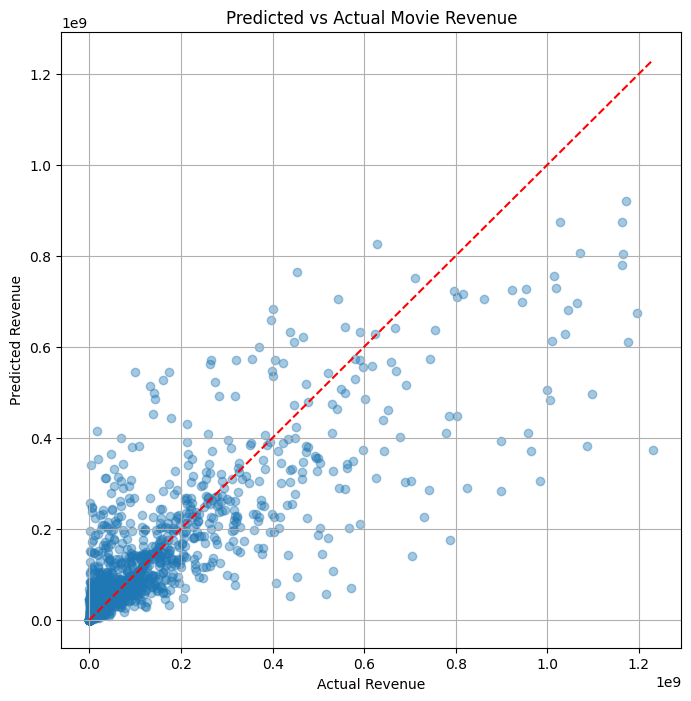

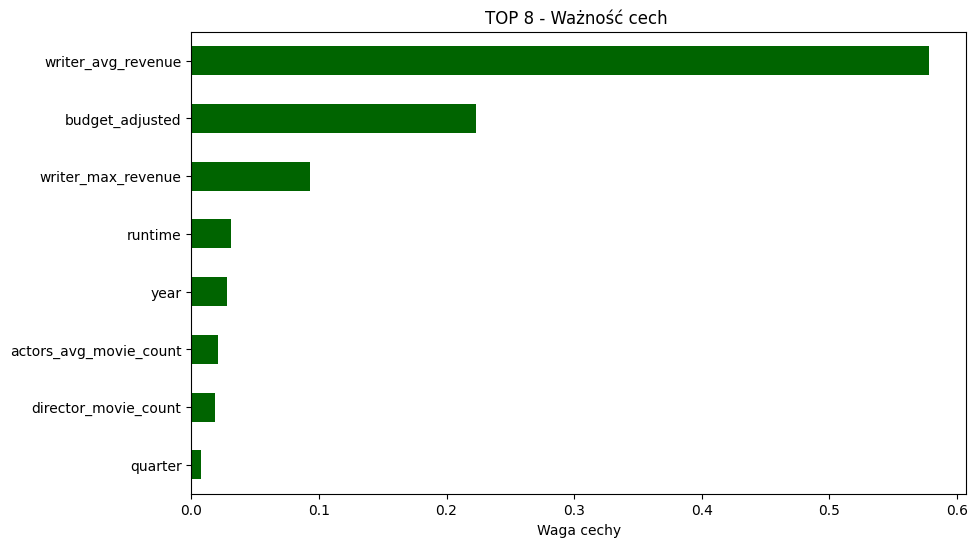

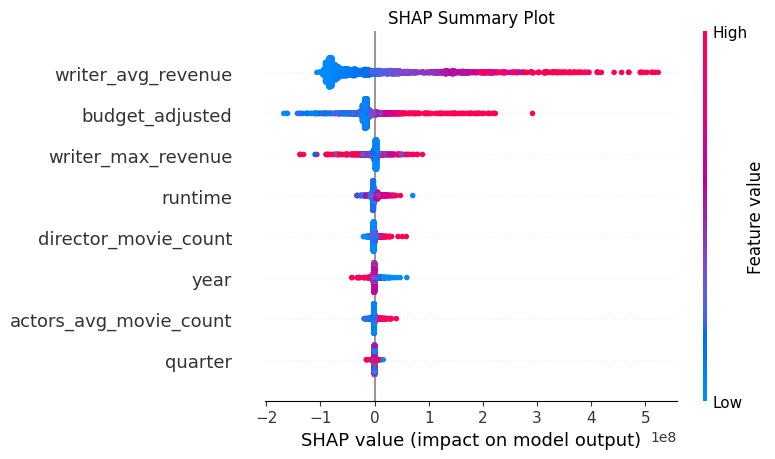

In [32]:
# MODEL Z TROCHĘ INNYMI CEHCHAMI WYODRĘBNIONYMI PRZEZ SHAP Z MODELU RF(20)

selected_features = [
    'runtime',
    'quarter',
    'budget_adjusted', 
    'year',
    'actors_avg_movie_count',
    'director_movie_count',
    'writer_max_revenue',
    'writer_avg_revenue'
]

print(f"WYBRANO {len(selected_features)} CECH")
for i, col in enumerate(selected_features, 1):
    print(f"{i}. {col}")


X_train_sub = X_train[selected_features]
X_test_sub = X_test[selected_features]
param_grid = {
    'n_estimators': [100, 300, 500, 600],
    'max_depth': [5, 10, 13, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4]
}

rf_cv = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10, 
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)


rf_cv.fit(X_train_sub, y_train)
best_rf = rf_cv.best_estimator_

print("\nNajlepsze parametry po Cross-Walidacji:")
print(rf_cv.best_params_)


y_pred_sub = best_rf.predict(X_test_sub)
evaluate_model(y_test, y_pred_sub)


# Ważność cech (Feature Importances)
importances_sub = pd.Series(best_rf.feature_importances_, index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_sub.plot(kind='barh', color='darkgreen').invert_yaxis()
plt.title("TOP 8 - Ważność cech ")
plt.xlabel("Waga cechy")
plt.show()

# SHAP
explainer_sub = shap.TreeExplainer(best_rf)
shap_values_sub = explainer_sub.shap_values(X_test_sub)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_sub, X_test_sub, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

# XGBoost

## Pełny model

WYNIKI MODELU
R^2 Score: 0.8809
MAE:        $28,702,591.31
RMSE:       $63,795,372.69
std:        $184,818,060.44


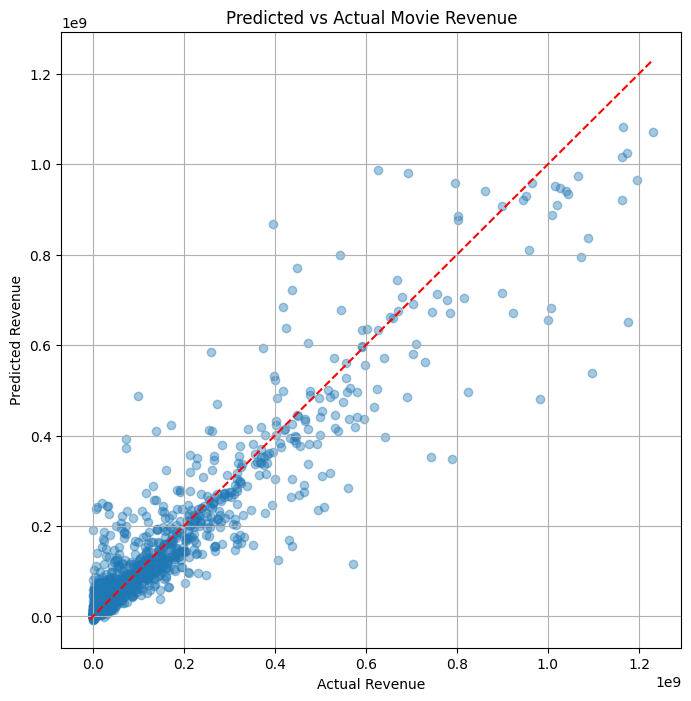

(28702591.31171427, 63795372.690179855, 0.8808512360616233)

In [33]:
xgb_model = xgb.XGBRegressor(learning_rate=0.03, subsample=0.9, n_estimators=500, min_child_weight=1, max_depth=7, gamma=0.3, colsample_bytree=0.9, objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

evaluate_model(y_test, y_pred)

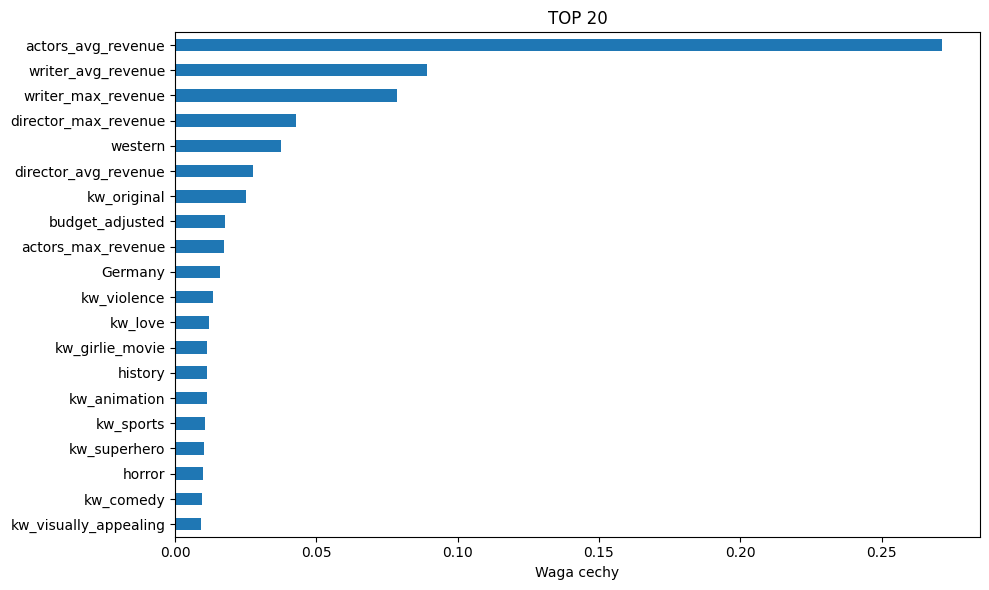

In [38]:
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

top_xgb_importances = xgb_importances.head(20)


plt.figure(figsize=(10, 6))
top_xgb_importances.plot(kind='barh').invert_yaxis()
plt.title("TOP 20")
plt.xlabel("Waga cechy")
plt.tight_layout()
plt.show()

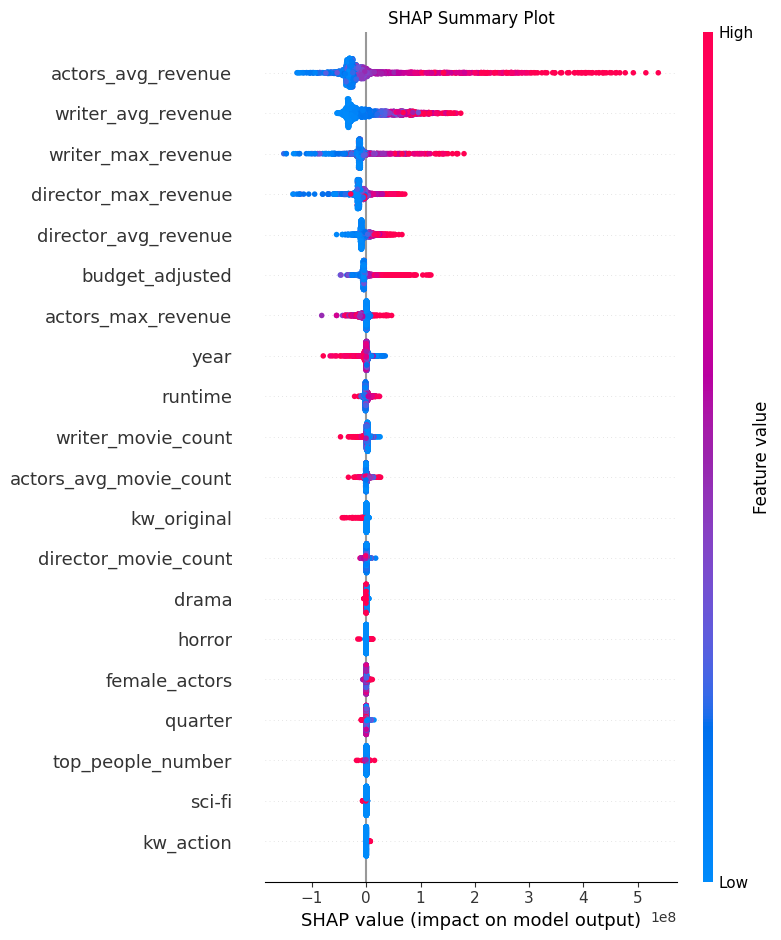

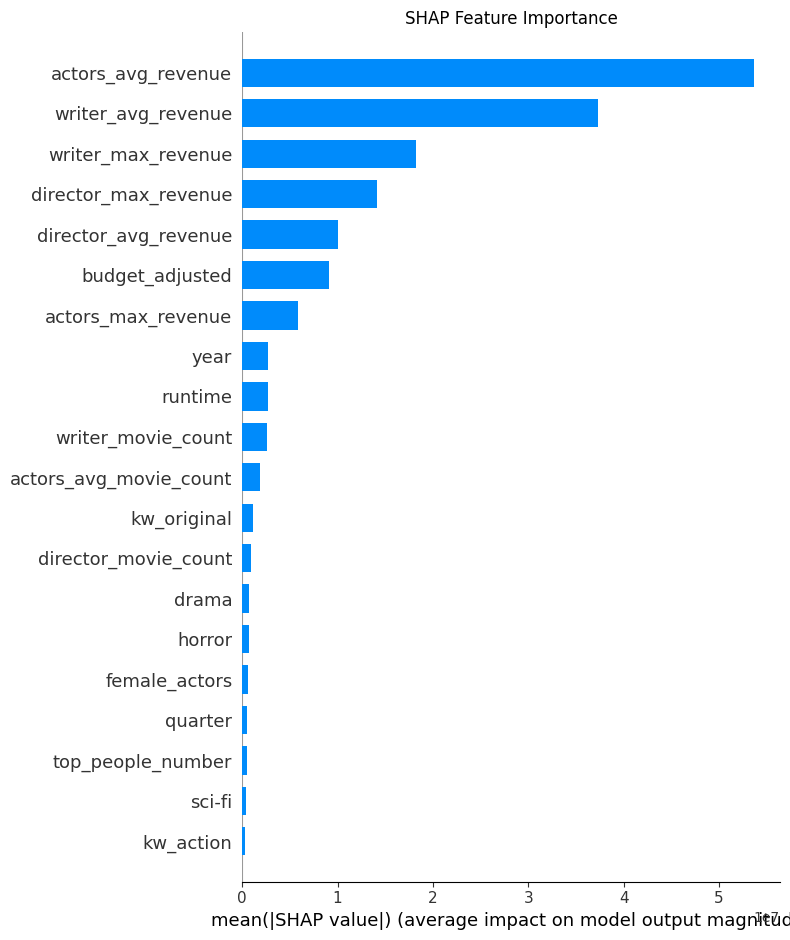

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test, check_additivity=False)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

## Zmniejszone modele

WYBRANO 10 NAJWAŻNIEJSZYCH CECH 
1. actors_avg_revenue
2. writer_avg_revenue
3. writer_max_revenue
4. director_max_revenue
5. western
6. director_avg_revenue
7. kw_original
8. budget_adjusted
9. actors_max_revenue
10. Germany

Najlepsze parametry po CV:
{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.9}
WYNIKI MODELU
R^2 Score: 0.8754
MAE:        $28,794,528.04
RMSE:       $65,245,235.31
std:        $184,818,060.44


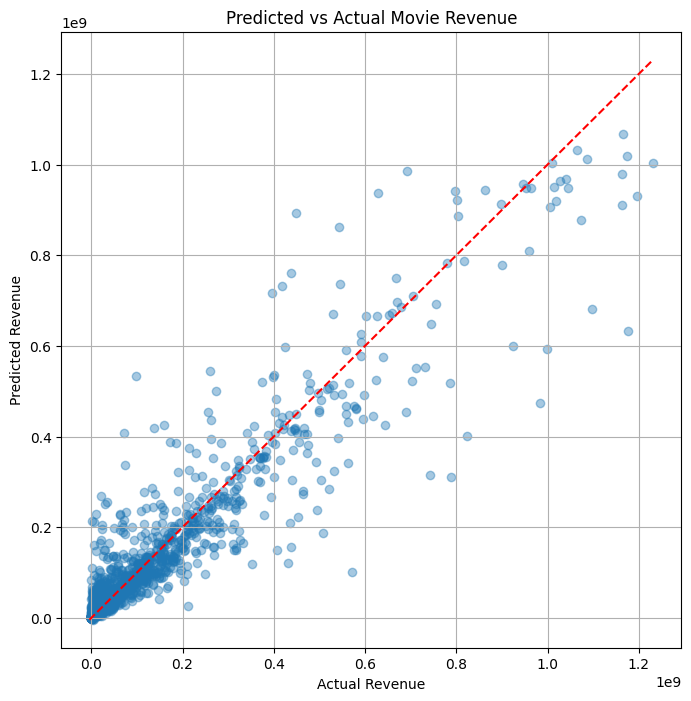

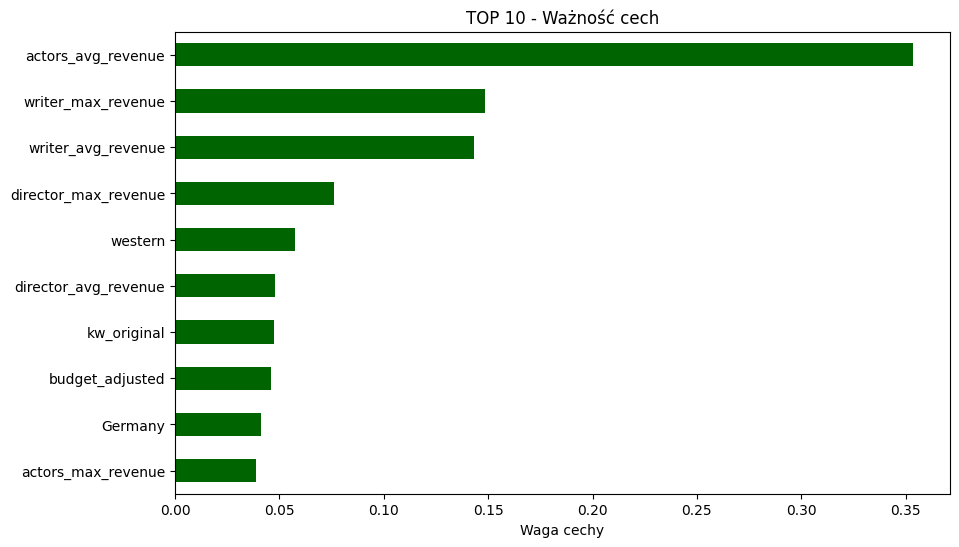

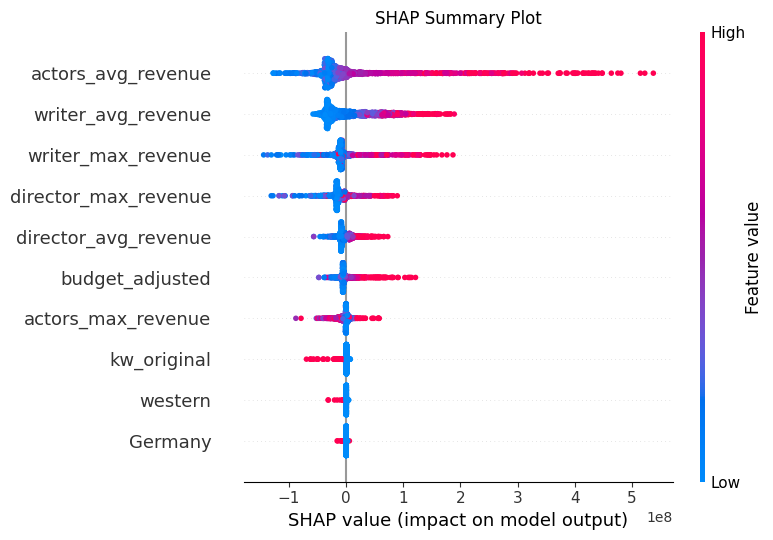

In [ ]:
# MODEL XGBOOST NAJWAŻNIEJSZE CECHY WG IMPORTANCE

TOP_N = 10  


top_features = xgb_importances.head(TOP_N).index.tolist()

print(f"WYBRANO {TOP_N} NAJWAŻNIEJSZYCH CECH ")
for i, col in enumerate(top_features, 1):
    print(f"{i}. {col}")


X_train_sub = X_train[top_features]
X_test_sub = X_test[top_features]


param_grid = {
    'n_estimators': [100, 300, 500, 600],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3]
}


xgb_cv = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_cv.fit(X_train_sub, y_train)
best_xgb = xgb_cv.best_estimator_

print("\nNajlepsze parametry po CV:")
print(xgb_cv.best_params_)


y_pred_sub = best_xgb.predict(X_test_sub)
evaluate_model(y_test, y_pred_sub) 


importances_sub = pd.Series(best_xgb.feature_importances_, index=top_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

importances_sub.plot(kind='barh', color='darkgreen').invert_yaxis()
plt.title(f"TOP {TOP_N} - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()


explainer_sub = shap.TreeExplainer(best_xgb)
shap_values_sub = explainer_sub.shap_values(X_test_sub, check_additivity=False)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_sub, X_test_sub, show=False)
plt.title(f"SHAP Summary Plot")
plt.tight_layout()
plt.show()

--- WYBRANO 7 NAJWAŻNIEJSZYCH CECH WEDŁUG SHAP ---
1. actors_avg_revenue
2. writer_avg_revenue
3. writer_max_revenue
4. director_max_revenue
5. director_avg_revenue
6. budget_adjusted
7. actors_max_revenue

Najlepsze parametry po CV:
{'subsample': 0.9, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.9}
WYNIKI MODELU
R^2 Score: 0.8822
MAE:        $28,279,685.46
RMSE:       $63,425,313.90
std:        $184,818,060.44


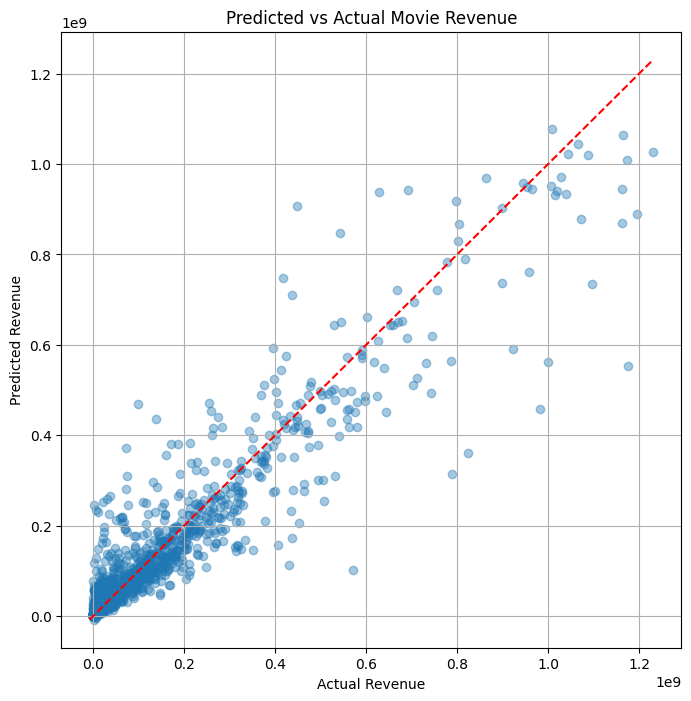

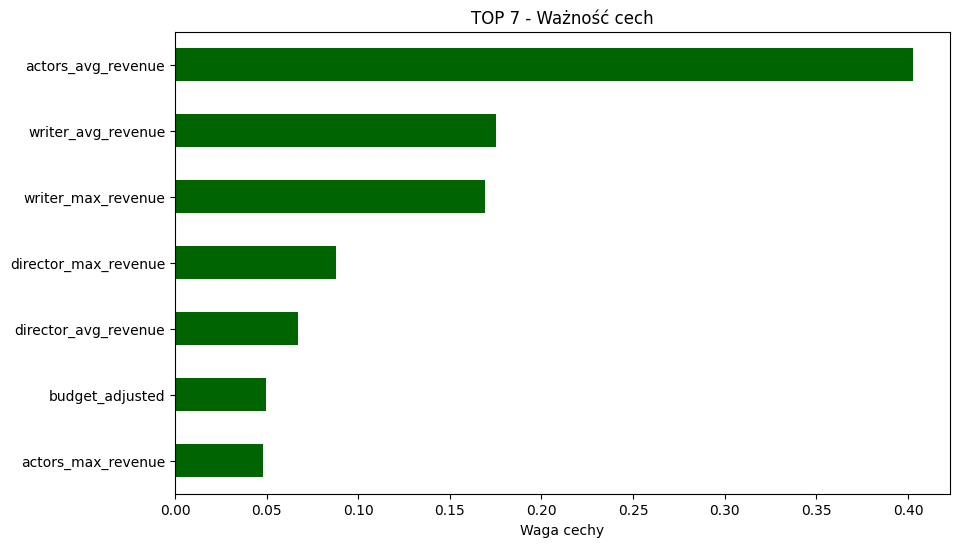

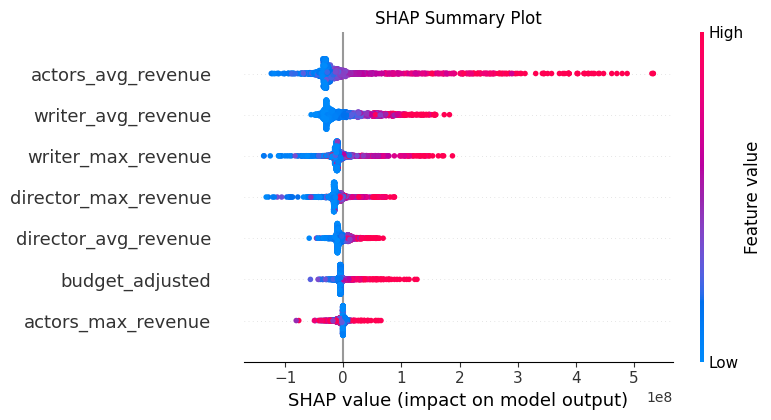

In [42]:
# MODEL XGBOOST TROCHE INNE NAJWAŻNIEJSZE CECHY WG SHAP


TOP_N = 7

mean_abs_shap = np.abs(shap_values).mean(axis=0)


shap_importance = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)

top_shap_features = shap_importance.head(TOP_N).index.tolist()

print(f"--- WYBRANO {TOP_N} NAJWAŻNIEJSZYCH CECH WEDŁUG SHAP ---")
for i, col in enumerate(top_shap_features, 1):
    print(f"{i}. {col}")


X_train_sub = X_train[top_shap_features]
X_test_sub = X_test[top_shap_features]

param_grid = {
    'n_estimators': [100, 300, 500, 600],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3]
}

xgb_cv = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_cv.fit(X_train_sub, y_train)
best_xgb = xgb_cv.best_estimator_

print("\nNajlepsze parametry po CV:")
print(xgb_cv.best_params_)

y_pred_sub = best_xgb.predict(X_test_sub)
evaluate_model(y_test, y_pred_sub) 


importances_sub = pd.Series(best_xgb.feature_importances_, index=top_shap_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_sub.plot(kind='barh', color='darkgreen').invert_yaxis()
plt.title(f"TOP {TOP_N} - Ważność cech")
plt.xlabel("Waga cechy")
plt.show()


explainer_sub = shap.TreeExplainer(best_xgb)

shap_values_sub = explainer_sub.shap_values(X_test_sub, check_additivity=False)

plt.figure(figsize=(10, 6))

shap.summary_plot(shap_values_sub, X_test_sub, show=False)
plt.title(f"SHAP Summary Plot")
plt.tight_layout()
plt.show()

# MLP

## Pełny model


Najlepsze parametry po CV:
{'learning_rate_init': 0.001, 'hidden_layer_sizes': (50,), 'alpha': 0.01, 'activation': 'relu'}
WYNIKI MODELU
R^2 Score: 0.8592
MAE:        $34,132,329.88
RMSE:       $69,347,781.29
std:        $184,818,060.44


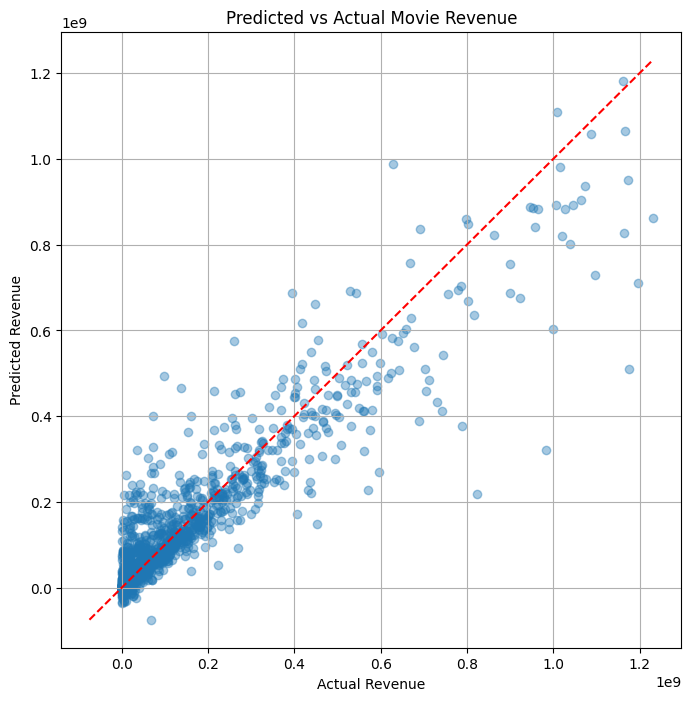

(34132329.87927433, 69347781.28518568, 0.8592085359447312)

In [48]:
from sklearn.neural_network import MLPRegressor


param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)], 
    'activation': ['relu', 'tanh'], 
    'alpha': [0.0001, 0.001, 0.01, 0.1], 
    'learning_rate_init': [0.001, 0.01] 
}

mlp_cv = RandomizedSearchCV(

    estimator=MLPRegressor(random_state=42, max_iter=2000, tol=0.1),
    param_distributions=param_grid,
    n_iter=10,  
    cv=3,   
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1 
)

mlp_cv.fit(X_train, y_train)

best_mlp = mlp_cv.best_estimator_

print("\nNajlepsze parametry po CV:")
print(mlp_cv.best_params_)


y_pred_mlp = best_mlp.predict(X_test)
evaluate_model(y_test, y_pred_mlp)

# KONRKETNE PRZYPADKI FILMÓW

## Najlepszy model jaki udało się wytrenować (RF z 20 cechami) - rf_najlepsze20

In [ ]:
# wyciągnięte z importances i zapisane do listy żeby było pod ręką

top20_features_rf = ['actors_avg_revenue', 'writer_max_revenue', 'writer_avg_revenue',
                     'director_max_revenue', 'budget_adjusted', 'actors_max_revenue',
                     'director_avg_revenue', 'year', 'writer_movie_count', 'actors_avg_movie_count',
                     'runtime', 'director_movie_count', 'quarter', 'top_people_number',
                     'female_actors', 'kw_original', 'western', 'drama', 'romance', 'kw_action']


WYNIKI MODELU
R^2 Score: 0.8820
MAE:        $27,972,211.64
RMSE:       $63,493,617.98
std:        $184,818,060.44


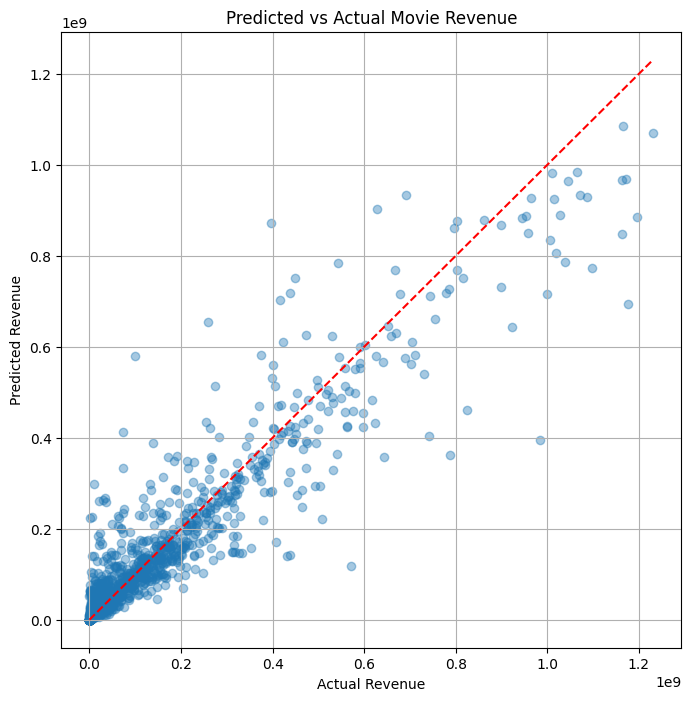

(27972211.635450583, 63493617.9756566, 0.8819757273373664)

In [56]:
X_train_sample = X_train[top20_features_rf]
X_test_sample = X_test[top20_features_rf]

rf_najlepszy20 = RandomForestRegressor(n_estimators=600, max_depth=13, min_samples_split=2, min_samples_leaf=3, n_jobs=-1, random_state=42)
rf_najlepszy20.fit(X_train_sample, y_train)

y_pred = rf_najlepszy20.predict(X_test_sample)

evaluate_model(y_test, y_pred)

In [61]:
# 1. Wczytujemy plik z tytułami (ten, który był bazą dla data_model)
df_titles = pd.read_csv('../data/merged/NEW_clean_data.csv')

# 2. Musimy przefiltrować tytuły tak samo, jak przefiltrowaliśmy ramkę 'data' (centyle 1%-99%)
# Wykorzystujemy indeksy z Twojej ramki 'data_filtered'
titles_filtered = df_titles.loc[data_filtered.index, 'title']

# 3. Robimy identyczny podział na zbiór treningowy i testowy dla tytułów
# Używamy tych samych parametrów: test_size=0.2 i random_state=42
_, titles_test = train_test_split(titles_filtered, test_size=0.2, random_state=42)

# 4. Tworzymy tabelę z wynikami
tytul_przewidywanie = pd.DataFrame({
    'Tytuł': titles_test.values,
    'Faktyczny Przychód': y_test.values,
    'Przewidywany Przychód': y_pred
})

# 5. Dodajemy kolumny w milionach dolarów dla lepszej czytelności
tytul_przewidywanie['Faktyczny (mln $)'] = (tytul_przewidywanie['Faktyczny Przychód'] / 1_000_000).round(2)
tytul_przewidywanie['Przewidywany (mln $)'] = (tytul_przewidywanie['Przewidywany Przychód'] / 1_000_000).round(2)
tytul_przewidywanie['Różnica (mln $)'] = (tytul_przewidywanie['Faktyczny (mln $)'] - tytul_przewidywanie ['Przewidywany (mln $)']).round(2)

In [67]:
tytul_przewidywanie.to_csv('../data/rf_tytul_przewidywania.csv', index=False)

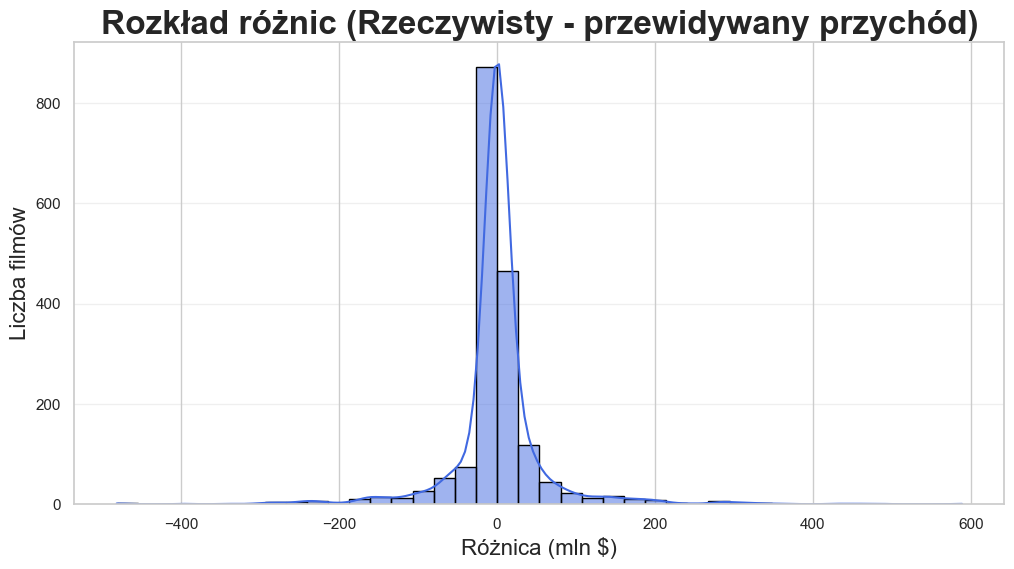

C:\Users\olkat\AppData\Local\Temp\ipykernel_19500\1855297909.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


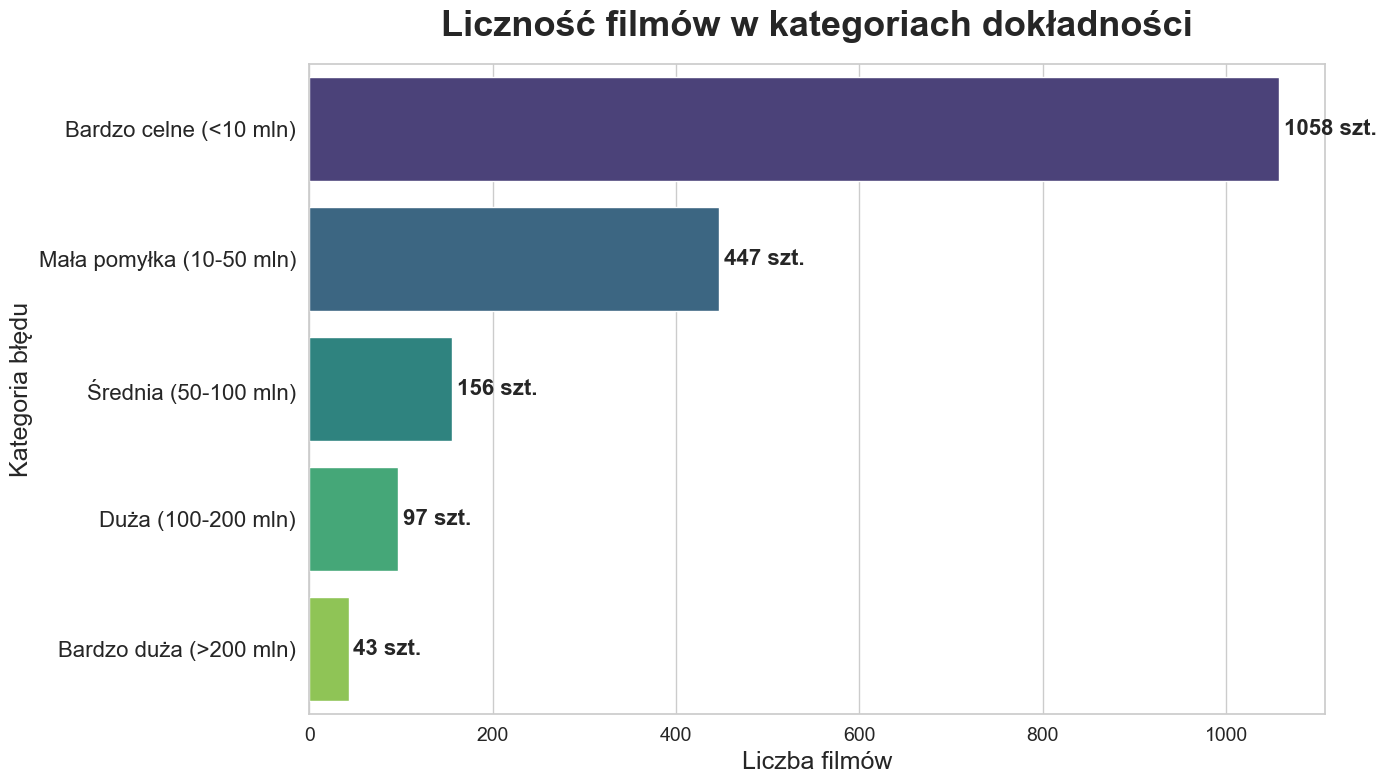

In [77]:

import seaborn as sns

df_plot = tytul_przewidywanie.copy()

bins = [0, 10, 50, 100, 200, float('inf')]
labels = [
    'Bardzo celne (<10 mln)', 
    'Mała pomyłka (10-50 mln)', 
    'Średnia (50-100 mln)', 
    'Duża (100-200 mln)', 
    'Bardzo duża (>200 mln)'
]


df_plot['Kategoria błędu'] = pd.cut(
    df_plot['Różnica (mln $)'].abs(), 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)


plt.figure(figsize=(12, 6))
sns.histplot(df_plot['Różnica (mln $)'], bins=40, kde=True, color='royalblue', edgecolor='black')
plt.title('Rozkład różnic (Rzeczywisty - przewidywany przychód)', fontsize=24, fontweight='bold')
plt.xlabel('Różnica (mln $)', fontsize=16)
plt.ylabel('Liczba filmów', fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.show()


plt.figure(figsize=(14, 8)) # Zwiększyłem nieco szerokość, żeby tekst się zmieścił
sns.countplot(
    data=df_plot, 
    y='Kategoria błędu', 
    palette='viridis', 
    order=labels 
)

# 1. POWIĘKSZENIE PODPISÓW "X szt."
for p in plt.gca().patches:
    width = p.get_width()
    plt.gca().text(
        width + 5, # Zwiększony odstęp od słupka, by większy tekst nie nachodził
        p.get_y() + p.get_height()/2, 
        f'{int(width)} szt.', 
        va='center', 
        fontsize=16, # Znacznie większa czcionka dla wartości
        fontweight='bold'
    )

# 2. POWIĘKSZENIE NAZW KATEGORII NA OSI Y
plt.yticks(fontsize=16) # To powiększy napisy "Bardzo celne", "Mała pomyłka" itd.
plt.xticks(fontsize=14) # Powiększenie liczb na osi X dla spójności

plt.title('Liczność filmów w kategoriach dokładności', fontsize=26, fontweight='bold', pad=20)
plt.xlabel('Liczba filmów', fontsize=18)
plt.ylabel('Kategoria błędu', fontsize=18)

plt.xlim(0, df_plot['Kategoria błędu'].value_counts().max() + 50) # Dodanie zapasu na osi X dla tekstów
plt.tight_layout()
plt.show()

In [ ]:
# Ttyuł oraz wszystkie cechy (niezakodowane, sprzed czyszczenia)

# 1. Wczytujemy plik z pełnymi metadanymi (ten, który ma imiona i teksty)
df_meta = pd.read_csv('../data/merged/NEW_clean_data.csv')


df_meta_filtered = df_meta.loc[data_filtered.index]


_, meta_test = train_test_split(df_meta_filtered, test_size=0.2, random_state=42)


analiza_ekspercka = meta_test.copy()


analiza_ekspercka['Faktyczny_mln'] = (y_test.values / 1_000_000).round(2)
analiza_ekspercka['Przewidywany_mln'] = (y_pred / 1_000_000).round(2)
analiza_ekspercka['Blad_mln'] = (analiza_ekspercka['Faktyczny_mln'] - analiza_ekspercka['Przewidywany_mln']).round(2)
analiza_ekspercka['Blad_bezwzgledny_mln'] = analiza_ekspercka['Blad_mln'].abs()

analiza_ekspercka.to_csv('../data/pelna_analiza_meta.csv', index=False)

C:\Users\olkat\AppData\Local\Temp\ipykernel_19500\61238616.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


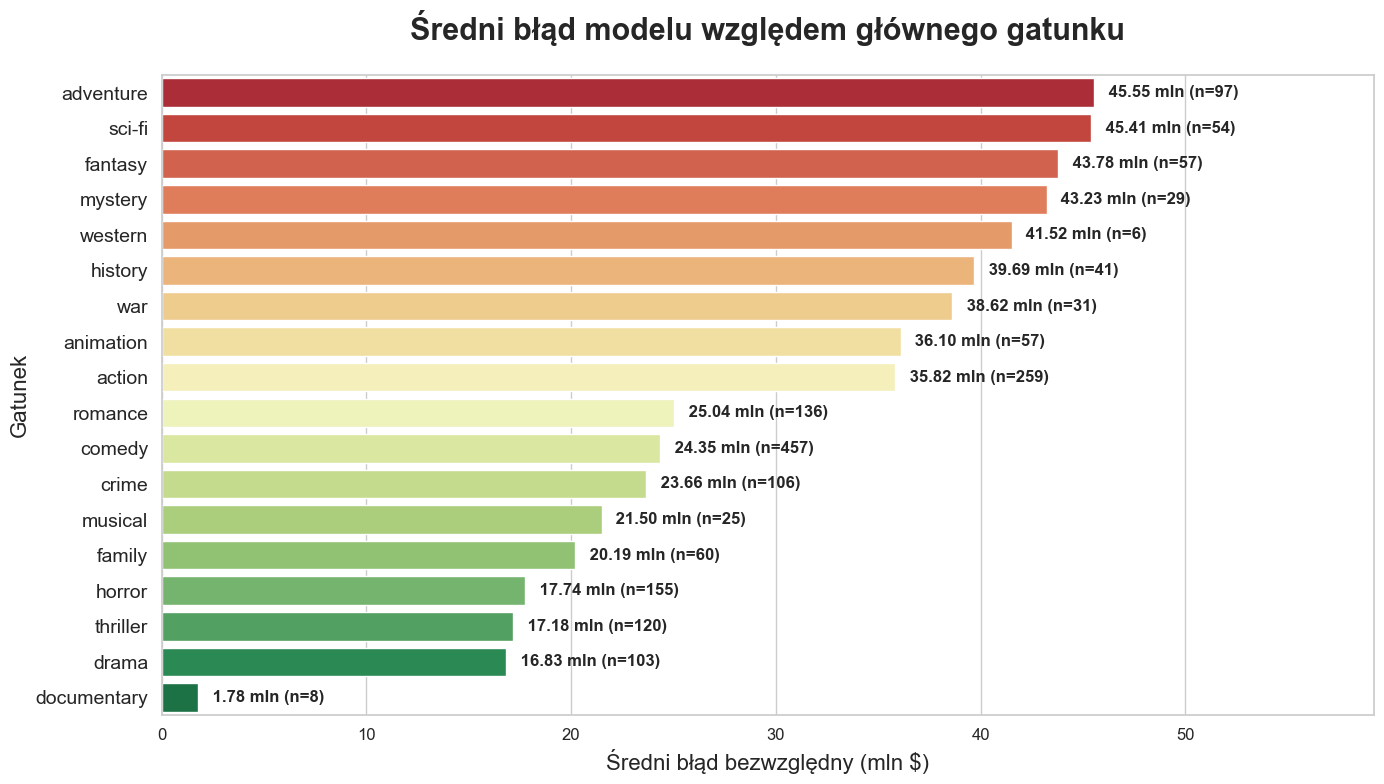

In [93]:

genre_analysis = analiza_ekspercka.groupby('main_genre').agg(
    sredni_blad=('Blad_bezwzgledny_mln', 'mean'),
    liczba_filmow=('Blad_bezwzgledny_mln', 'count')
).reset_index()


genre_analysis = genre_analysis.sort_values('sredni_blad', ascending=False)


plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

barplot = sns.barplot(
    data=genre_analysis, 
    x='sredni_blad', 
    y='main_genre', 
    palette='RdYlGn'
)


for i, p in enumerate(barplot.patches):
    val = genre_analysis.iloc[i]['sredni_blad']
    n = genre_analysis.iloc[i]['liczba_filmow']
    
    barplot.annotate(f' {val:.2f} mln (n={int(n)})', 
                     (p.get_width(), p.get_y() + p.get_height()/2),
                     xytext=(7, 0), textcoords='offset points', 
                     va='center', fontsize=12, fontweight='bold')


plt.title('Średni błąd modelu względem głównego gatunku', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('Średni błąd bezwzględny (mln $)', fontsize=16)
plt.ylabel('Gatunek', fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=12)


plt.xlim(0, genre_analysis['sredni_blad'].max() * 1.3)

plt.tight_layout()
plt.show()

C:\Users\olkat\AppData\Local\Temp\ipykernel_19500\3561258462.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


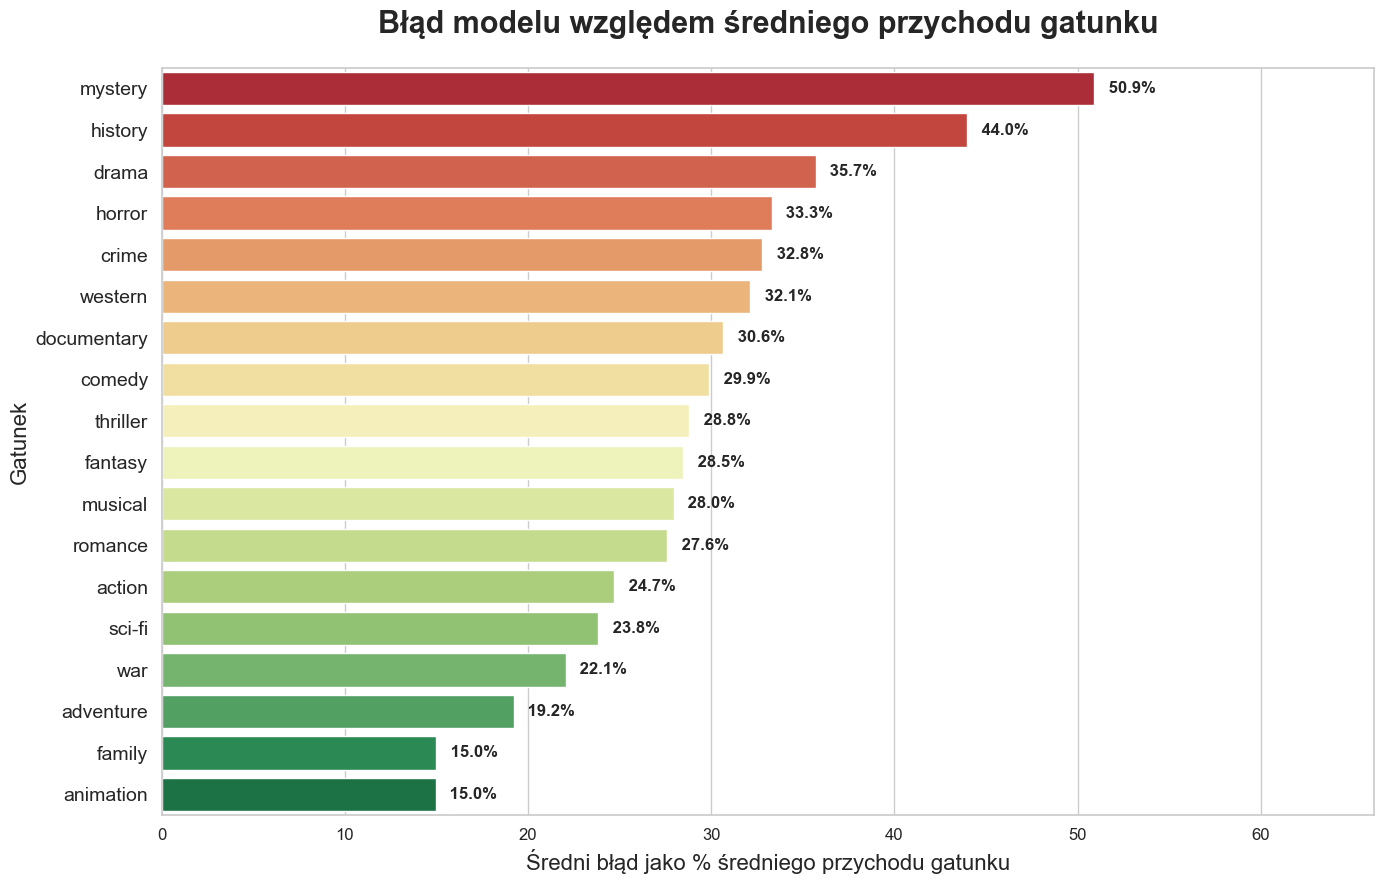

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


genre_norm = analiza_ekspercka.groupby('main_genre').agg(
    sredni_przychod=('Faktyczny_mln', 'mean'),
    sredni_blad=('Blad_bezwzgledny_mln', 'mean'),
    liczba_filmow=('Blad_bezwzgledny_mln', 'count')
).reset_index()


genre_norm['Blad_relatywny_procent'] = (genre_norm['sredni_blad'] / genre_norm['sredni_przychod']) * 100


genre_norm = genre_norm.sort_values('Blad_relatywny_procent', ascending = False)


plt.figure(figsize=(14, 9))
sns.set_theme(style="whitegrid")


barplot = sns.barplot(
    data=genre_norm, 
    x='Blad_relatywny_procent', 
    y='main_genre', 
    palette='RdYlGn'
)


for i, p in enumerate(barplot.patches):
    procent = genre_norm.iloc[i]['Blad_relatywny_procent']
    n = genre_norm.iloc[i]['liczba_filmow']
    przychod = genre_norm.iloc[i]['sredni_przychod']
    
    barplot.annotate(f' {procent:.1f}%', 
                     (p.get_width(), p.get_y() + p.get_height()/2),
                     xytext=(7, 0), textcoords='offset points', 
                     va='center', fontsize=12, fontweight='bold')

plt.title('Błąd modelu względem średniego przychodu gatunku', fontsize=22, fontweight='bold', pad=25)
plt.xlabel('Średni błąd jako % średniego przychodu gatunku', fontsize=16)
plt.ylabel('Gatunek', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)


avg_rel_err = genre_norm['Blad_relatywny_procent'].mean()

plt.xlim(0, genre_norm['Blad_relatywny_procent'].max() * 1.3)
plt.tight_layout()
plt.show()

C:\Users\olkat\AppData\Local\Temp\ipykernel_19500\1208979907.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


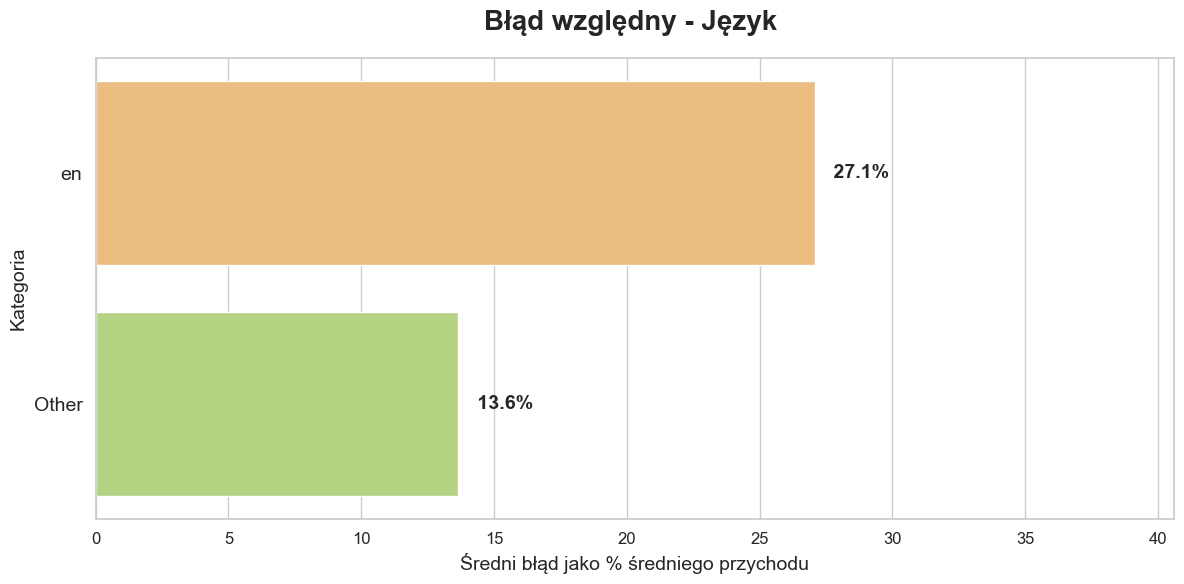

C:\Users\olkat\AppData\Local\Temp\ipykernel_19500\1208979907.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


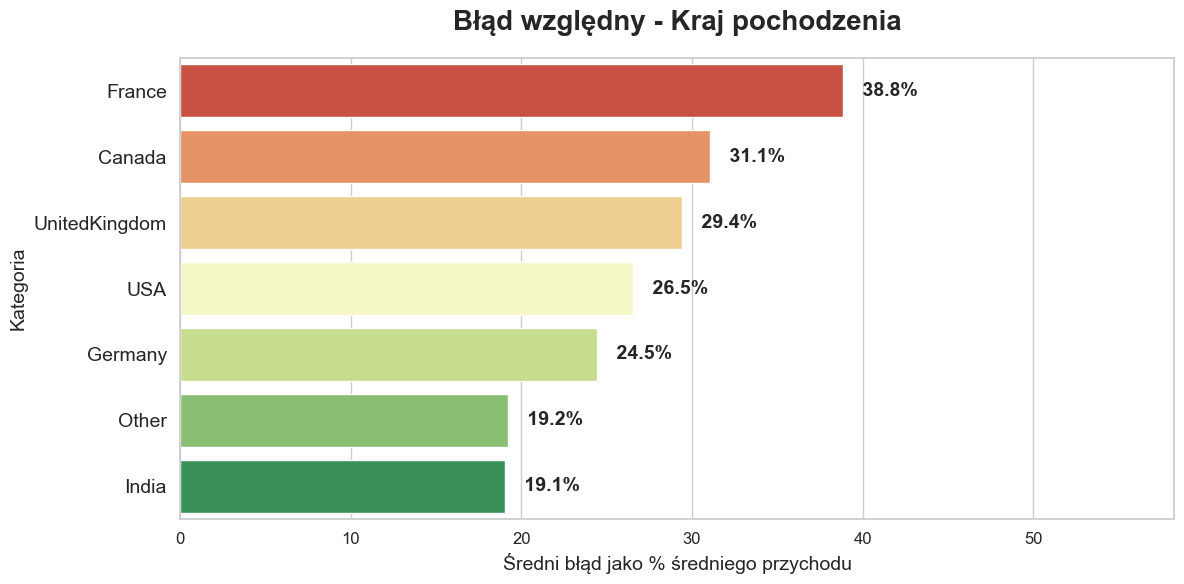

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df_plot = analiza_ekspercka.copy()


df_plot['lang_grouped'] = np.where(df_plot['original_language'] == 'en', 'en', 'Other')


kraje_glowne = ['Canada', 'France', 'Germany', 'India', 'UnitedKingdom', 'USA']
df_plot['country_grouped'] = df_plot['main_country'].apply(lambda x: x if x in kraje_glowne else 'Other')


def plot_grouped_relative_error(df, kolumna, tytul):
    # Agregacja
    stats = df.groupby(kolumna).agg(
        sredni_przychod=('Faktyczny_mln', 'mean'),
        sredni_blad=('Blad_bezwzgledny_mln', 'mean'),
        liczba_filmow=('Blad_bezwzgledny_mln', 'count')
    ).reset_index()

    # Obliczenie błędu %
    stats['Blad_relatywny_procent'] = (stats['sredni_blad'] / stats['sredni_przychod']) * 100
    
    # Sortowanie: od najgorzej przewidywanych (największy %)
    stats = stats.sort_values('Blad_relatywny_procent', ascending=False)

    # Wykres
    plt.figure(figsize=(12, 6)) # Nieco niższy wykres, bo kategorii jest mało
    sns.set_theme(style="whitegrid")
    
    barplot = sns.barplot(
        data=stats, 
        x='Blad_relatywny_procent', 
        y=kolumna, 
        palette='RdYlGn'
    )

    # Podpisy na słupkach
    for i, p in enumerate(barplot.patches):
        procent = stats.iloc[i]['Blad_relatywny_procent']
        n = stats.iloc[i]['liczba_filmow']
        przychod = stats.iloc[i]['sredni_przychod']
        
        barplot.annotate(f' {procent:.1f}%', 
                         (p.get_width(), p.get_y() + p.get_height()/2),
                         xytext=(10, 0), textcoords='offset points', 
                         va='center', fontsize=14, fontweight='bold')

    plt.title(tytul, fontsize=20, fontweight='bold', pad=20)
    plt.xlabel('Średni błąd jako % średniego przychodu', fontsize=14)
    plt.ylabel('Kategoria', fontsize=14)
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=12)
    plt.xlim(0, stats['Blad_relatywny_procent'].max() * 1.5) # Zapas na napisy
    
    plt.tight_layout()
    plt.show()




plot_grouped_relative_error(df_plot, 'lang_grouped', 'Błąd względny - Język ')

# Wykres 2: Kraje
plot_grouped_relative_error(df_plot, 'country_grouped', 'Błąd względny - Kraj pochodzenia')

C:\Users\olkat\AppData\Local\Temp\ipykernel_19500\2369306384.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot1 = sns.barplot(data=stats_top, x='Top People', y='sredni_blad', palette=['#ff9999', '#66b3ff'])


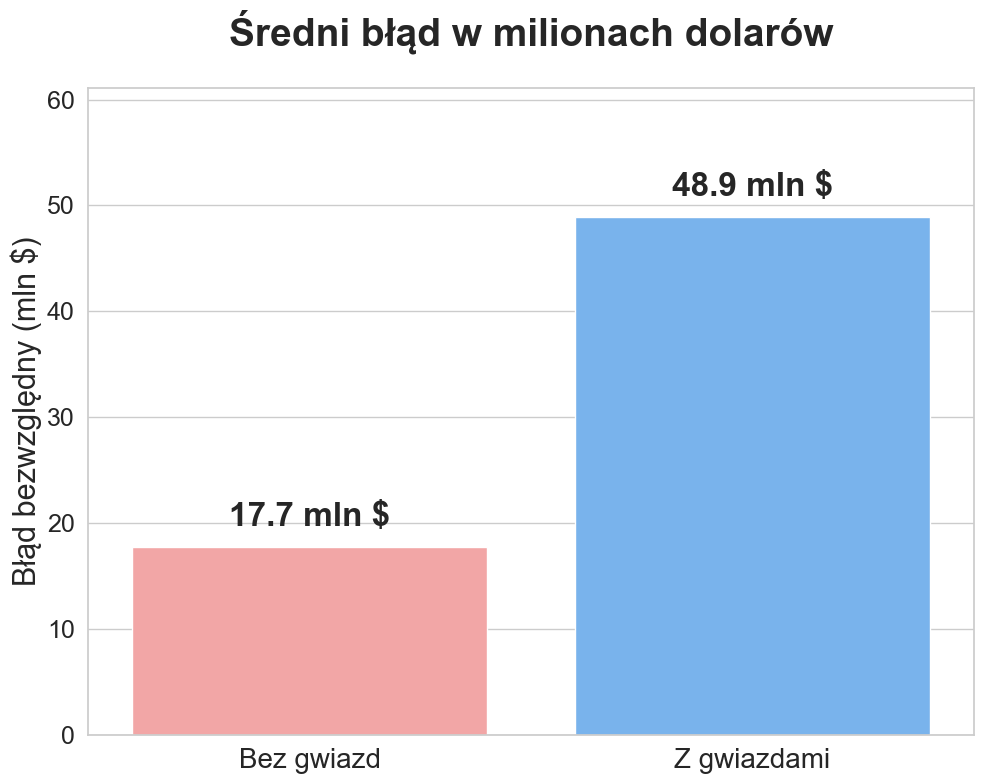

C:\Users\olkat\AppData\Local\Temp\ipykernel_19500\2369306384.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot2 = sns.barplot(data=stats_top, x='Top People', y='Blad_relatywny_procent', palette=['#ff9999', '#66b3ff'])


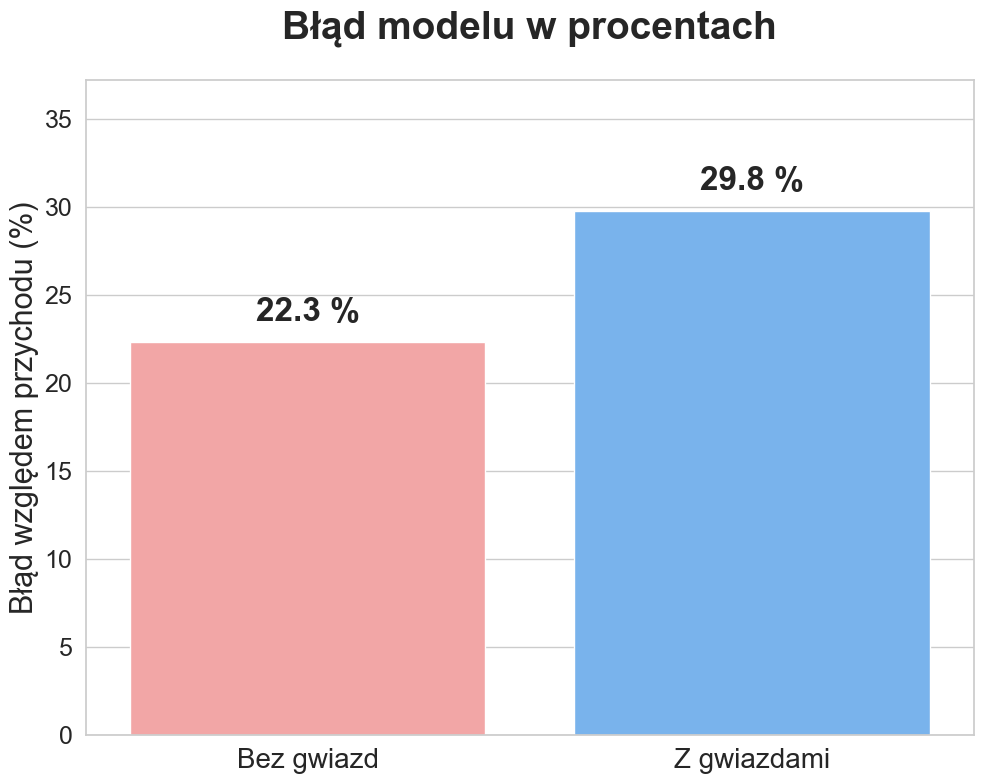

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df_plot = analiza_ekspercka.copy()


df_plot['Top People'] = np.where(df_plot['top_people'] == True, 'Z gwiazdami', 'Bez gwiazd')


stats_top = df_plot.groupby('Top People').agg(
    sredni_przychod=('Faktyczny_mln', 'mean'),
    sredni_blad=('Blad_bezwzgledny_mln', 'mean')
).reset_index()


stats_top['Blad_relatywny_procent'] = (stats_top['sredni_blad'] / stats_top['sredni_przychod']) * 100


plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

barplot1 = sns.barplot(data=stats_top, x='Top People', y='sredni_blad', palette=['#ff9999', '#66b3ff'])


for i, p in enumerate(barplot1.patches):
    val = stats_top.iloc[i]['sredni_blad']
    barplot1.annotate(f"{val:.1f} mln $", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=24, fontweight='bold', 
                     xytext=(0, 10), textcoords='offset points')

plt.title('Średni błąd w milionach dolarów', fontsize=28, fontweight='bold', pad=30)
plt.ylabel('Błąd bezwzględny (mln $)', fontsize=22)
plt.xlabel('', fontsize=22) 
plt.xticks(fontsize=20)
plt.yticks(fontsize=18)
plt.ylim(0, stats_top['sredni_blad'].max() * 1.25) 
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 8))

barplot2 = sns.barplot(data=stats_top, x='Top People', y='Blad_relatywny_procent', palette=['#ff9999', '#66b3ff'])


for i, p in enumerate(barplot2.patches):
    val = stats_top.iloc[i]['Blad_relatywny_procent']
    barplot2.annotate(f"{val:.1f} %", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=24, fontweight='bold', 
                     xytext=(0, 10), textcoords='offset points')

plt.title('Błąd modelu w procentach', fontsize=28, fontweight='bold', pad=30)
plt.ylabel('Błąd względem przychodu (%)', fontsize=22)
plt.xlabel('', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=18)
plt.ylim(0, stats_top['Blad_relatywny_procent'].max() * 1.25)
plt.tight_layout()
plt.show()

C:\Users\olkat\AppData\Local\Temp\ipykernel_19500\2011847025.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_q = sns.barplot(data=stats_kwartal, x='Kwartał', y='Blad_bezwzgledny_mln', palette='coolwarm')


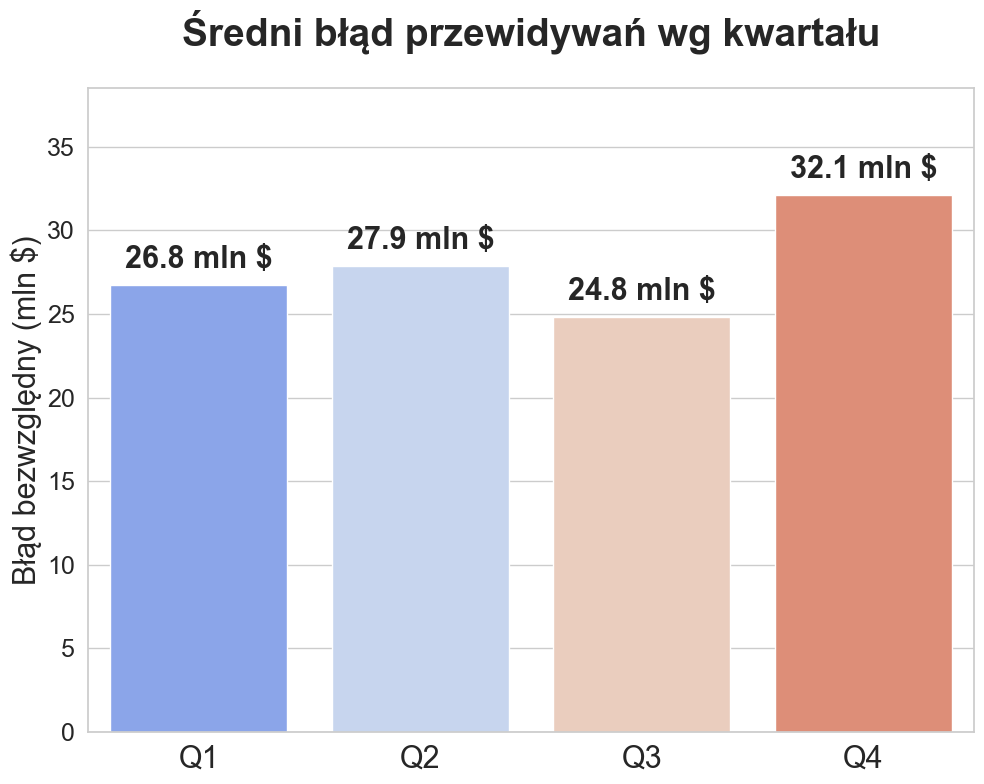

C:\Users\olkat\AppData\Local\Temp\ipykernel_19500\2011847025.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_y = sns.barplot(data=stats_rok, x='year', y='Blad_bezwzgledny_mln', palette='viridis')


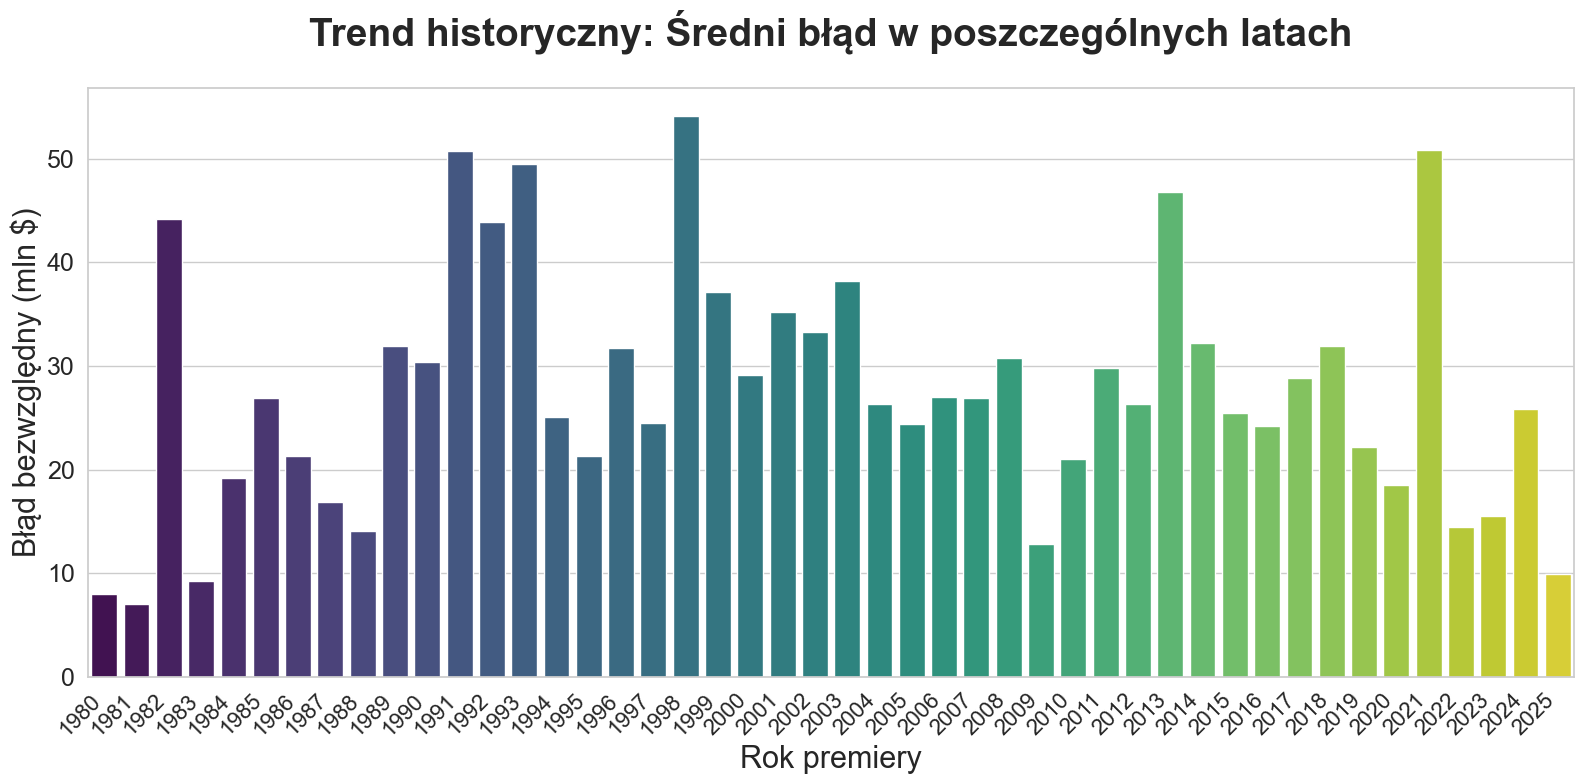

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


df_plot = analiza_ekspercka.copy()


df_plot['release_date'] = pd.to_datetime(df_plot['release_date'])
df_plot['Kwartał'] = df_plot['release_date'].dt.quarter


stats_kwartal = df_plot.groupby('Kwartał')['Blad_bezwzgledny_mln'].mean().reset_index()
stats_kwartal['Kwartał'] = 'Q' + stats_kwartal['Kwartał'].astype(int).astype(str) # Zamiana na Q1, Q2...


stats_rok = df_plot.groupby('year')['Blad_bezwzgledny_mln'].mean().reset_index()
stats_rok = stats_rok.sort_values('year')

sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 8))
barplot_q = sns.barplot(data=stats_kwartal, x='Kwartał', y='Blad_bezwzgledny_mln', palette='coolwarm')


for p in barplot_q.patches:
    barplot_q.annotate(f"{p.get_height():.1f} mln $", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=22, fontweight='bold', 
                     xytext=(0, 8), textcoords='offset points')

plt.title('Średni błąd przewidywań wg kwartału', fontsize=28, fontweight='bold', pad=30)
plt.ylabel('Błąd bezwzględny (mln $)', fontsize=22)
plt.xlabel('', fontsize=22)
plt.xticks(fontsize=22)
plt.yticks(fontsize=18)
plt.ylim(0, stats_kwartal['Blad_bezwzgledny_mln'].max() * 1.2)
plt.tight_layout()
plt.show()


plt.figure(figsize=(16, 8)) 
barplot_y = sns.barplot(data=stats_rok, x='year', y='Blad_bezwzgledny_mln', palette='viridis')

plt.title('Trend historyczny: Średni błąd w poszczególnych latach', fontsize=28, fontweight='bold', pad=30)
plt.ylabel('Błąd bezwzględny (mln $)', fontsize=22)
plt.xlabel('Rok premiery', fontsize=22)
plt.xticks(rotation=45, ha='right', fontsize=16) 
plt.yticks(fontsize=18)


plt.tight_layout()
plt.show()